In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import mujoco
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/mujoco',
        '--file_name', 'hopper',
        '--data_nsample_all', '9850',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--feature_ndim', '14',
        '--target_ndim', '11',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/mujoco',

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 10, "cos": 10}',
        '--embed_exc', '{"data": 20}',
    ]
)

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + '20260314_kind_hopper_checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

setpoint = torch.zeros(args.target_ndim)

dataset = mujoco.dataset(args, setpoint, load_normalized=False, extract_windows=False)
model = kind.model_adapter(model, dataset.normalizer)

shape of read Hopper trajectory: torch.Size([1, 9850, 14])


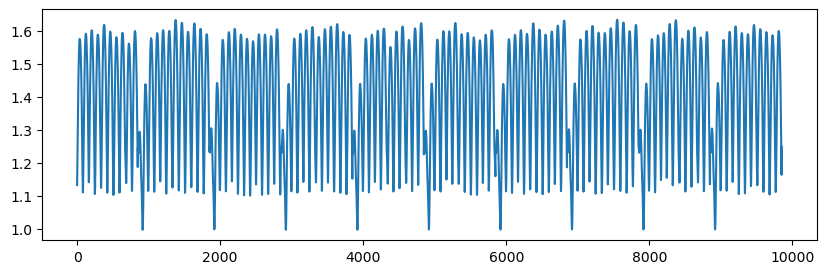

In [3]:
skip_nsample = 150
traj_nsample = 10_000 - skip_nsample
traj_true = util_data.read_datafile('../../data/mujoco/hopper_all_0', traj_nsample)
print(f'shape of read Hopper trajectory: {traj_true.shape}')

plt.figure(figsize=(10,3))
plt.plot(traj_true[0, :, 0])
plt.show()


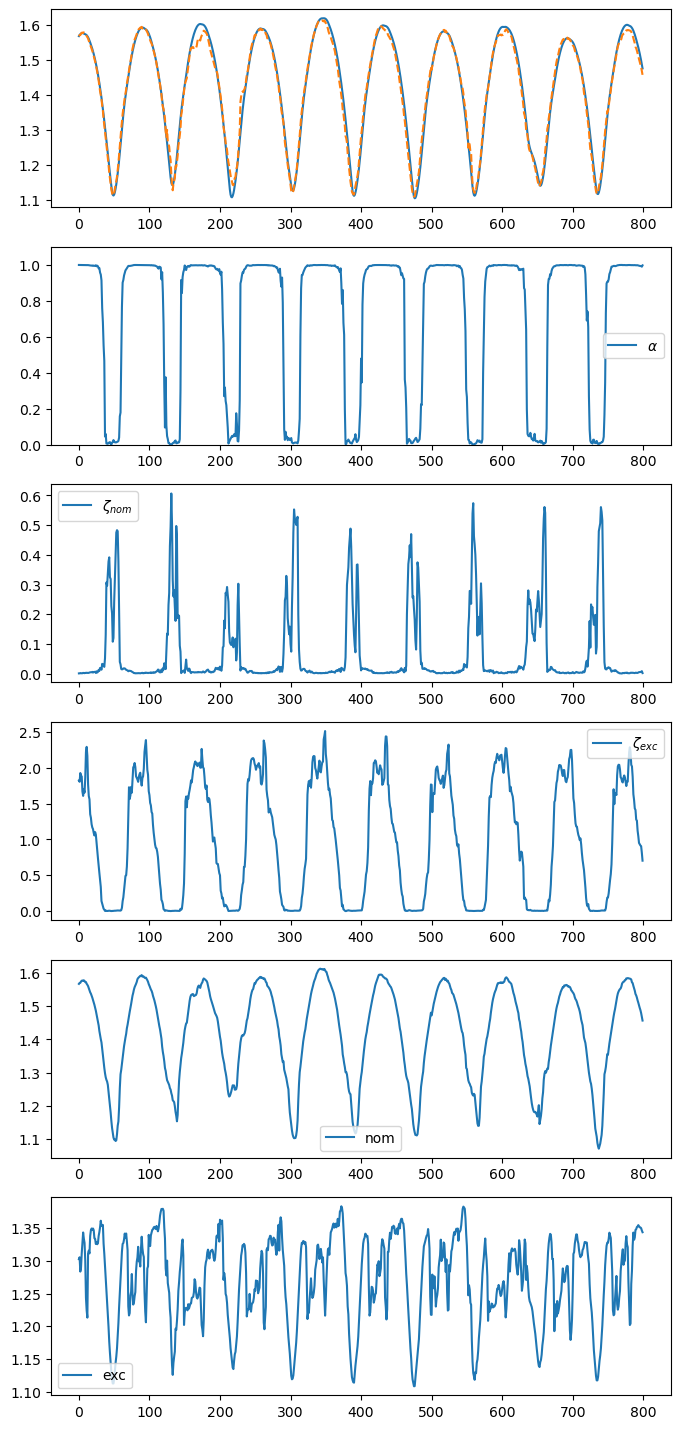

In [4]:
# --! perform model rollout --!

# --! we use this dummy replay just to get access to replay utilities
dummy_replay = mujoco.replay(s_ndim=11, a_ndim=3)

offset = 0
h = 800 # rollout length
rollout_nsample = 250 # re-anchor after this number of samples

next_ss = []
alphas = []
means_nom = []
means_exc = []
zetas_nom = []
zetas_exc = []

back = traj_true[:, offset:offset + args.back_nsample].clone()
true = traj_true[:, offset + args.back_nsample:offset + args.back_nsample + h]

with torch.no_grad():

    for k in range(h):
        if k % rollout_nsample == 0:
            t2 = offset + args.back_nsample + k
            t1 = t2 - args.back_nsample
            back = traj_true[:, t1:t2].clone()

        s = dummy_replay.util.get_s(back)
        t = offset + k + args.back_nsample - 1
        a = traj_true[:, [t], -(dummy_replay.util.a_ndim + 1):]

        dummy_replay.util.update_a(back, a)
        model_o = model(back)

        fore = model_o.blend[:, args.back_nsample:]
        next_s = fore[:, :1]
        back = dummy_replay.util.shift_obs(back, next_s)

        alpha = model_o.alpha[:, args.back_nsample:]
        alpha = alpha[:, :1]

        zeta_nom = model_o.zeta_nom[:, args.back_nsample:]
        zeta_nom = zeta_nom[:, :1]

        zeta_exc = model_o.zeta_exc[:, args.back_nsample:]
        zeta_exc = zeta_exc[:, :1]

        mean_nom = model_o.mean_nom[:, args.back_nsample:]
        mean_nom = mean_nom[:, :1]

        mean_exc = model_o.mean_exc[:, args.back_nsample:]
        mean_exc = mean_exc[:, :1]

        next_ss.append(next_s)
        alphas.append(alpha)
        zetas_nom.append(zeta_nom)
        zetas_exc.append(zeta_exc)
        means_nom.append(mean_nom)
        means_exc.append(mean_exc)

    next_ss = torch.cat(next_ss, dim=1)
    alphas = torch.cat(alphas, dim=1)
    zetas_nom = torch.cat(zetas_nom, dim=1)
    zetas_exc = torch.cat(zetas_exc, dim=1)
    means_nom = torch.cat(means_nom, dim=1)
    means_exc = torch.cat(means_exc, dim=1)

    plt.figure(figsize=(8,18))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(next_ss[0, :, 0], linestyle='dashed')

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()

    plt.show()

## Save rollout data

In [6]:
datasaved = True

if datasaved:
    step = torch.arange(true.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        true[..., :1], next_ss[..., :1], alphas[..., :1], zetas_nom[..., :1]], axis=2)
    util_data.write_datafile(f'../../results/mujoco/hopper_kind_rollout_reanchor_250', savedata, delim=' ')